In [1]:
library(stats)
library(tidyverse)
library(ggplot2)
library(patchwork)
library(car)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ purrr::%||%()   masks base::%||%()
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


The following object is masked from ‘package:purrr’:

    some




# Check if model is correctly specified


## Omitted variables

If there are some important variables that we did not include in the model, then the estimates of the parameters might be biased and in some cases quite seriously (e.g. positive sign instead of the negative one). A classical example of model with omitted important variables is simple linear regression, which by definition includes only one explanatory variable. Making decisions based on such model might not be wise, as it might mislead about the significance and sign of effects. Finally, when it comes to forecasting, omitting important variables is equivalent to underfitting the data, ignoring significant aspects of the model. This means that the point forecasts from the model might be biased (systematic under or over forecasting), the variance of the error term will be higher than needed, which will result in wider than necessary prediction interval.


In [2]:
set.seed(1)
n <- 100
x1 <- rnorm(n, mean = 5, sd = 2)
x2 <- rpois(n, lambda = 10)
x3 <- rpois(n, lambda = 1)
y <- 3 + (2 * x1) + (1.5 * x2) + (3 * x3) + rnorm(n, mean = 0, sd = 2) # The observed data is a function of the 2 variables x1 and x2

df <- data.frame(x1 = x1, x2 = x2, x3 = x3, y = y)
head(df)


,x1,x2,x3,y
,<dbl>,<int>,<int>,<dbl>
1,3.747092,8,0,18.71413
2,5.367287,10,1,30.55495
3,3.328743,7,1,19.72848
4,8.190562,6,0,27.53913
5,5.659016,15,2,43.43831
6,3.359063,12,2,37.12327


In [3]:
model1 <- lm(formula = y ~ x1, data = df)
summary(model1)



Call:
lm(formula = y ~ x1, data = df)

Residuals:
     Min       1Q   Median       3Q      Max 
-11.5466  -4.5349  -0.5704   3.7807  17.8914 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   19.581      1.892  10.351  < 2e-16 ***
x1             2.208      0.343   6.439 4.48e-09 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6.13 on 98 degrees of freedom
Multiple R-squared:  0.2973,	Adjusted R-squared:  0.2901 
F-statistic: 41.46 on 1 and 98 DF,  p-value: 4.48e-09


In [4]:
model2 <- lm(formula = y ~ x1 + x2, data = df)
summary(model2)



Call:
lm(formula = y ~ x1 + x2, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-6.9908 -2.8250 -0.2765  2.7339  9.2147 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   6.1121     1.5821   3.863 0.000202 ***
x1            2.0313     0.2124   9.563 1.18e-15 ***
x2            1.4977     0.1185  12.634  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.788 on 97 degrees of freedom
Multiple R-squared:  0.7344,	Adjusted R-squared:  0.7289 
F-statistic: 134.1 on 2 and 97 DF,  p-value: < 2.2e-16


In [5]:
model3 <- lm(formula = y ~ x1 + x2 + x3, data = df)
summary(model3)



Call:
lm(formula = y ~ x1 + x2 + x3, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.6445 -1.1799  0.1120  0.9866  3.8813 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.26538    0.74976   3.021  0.00322 ** 
x1           2.20695    0.09743  22.651  < 2e-16 ***
x2           1.42928    0.05425  26.345  < 2e-16 ***
x3           3.32180    0.17291  19.211  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.73 on 96 degrees of freedom
Multiple R-squared:  0.9452,	Adjusted R-squared:  0.9435 
F-statistic: 551.6 on 3 and 96 DF,  p-value: < 2.2e-16


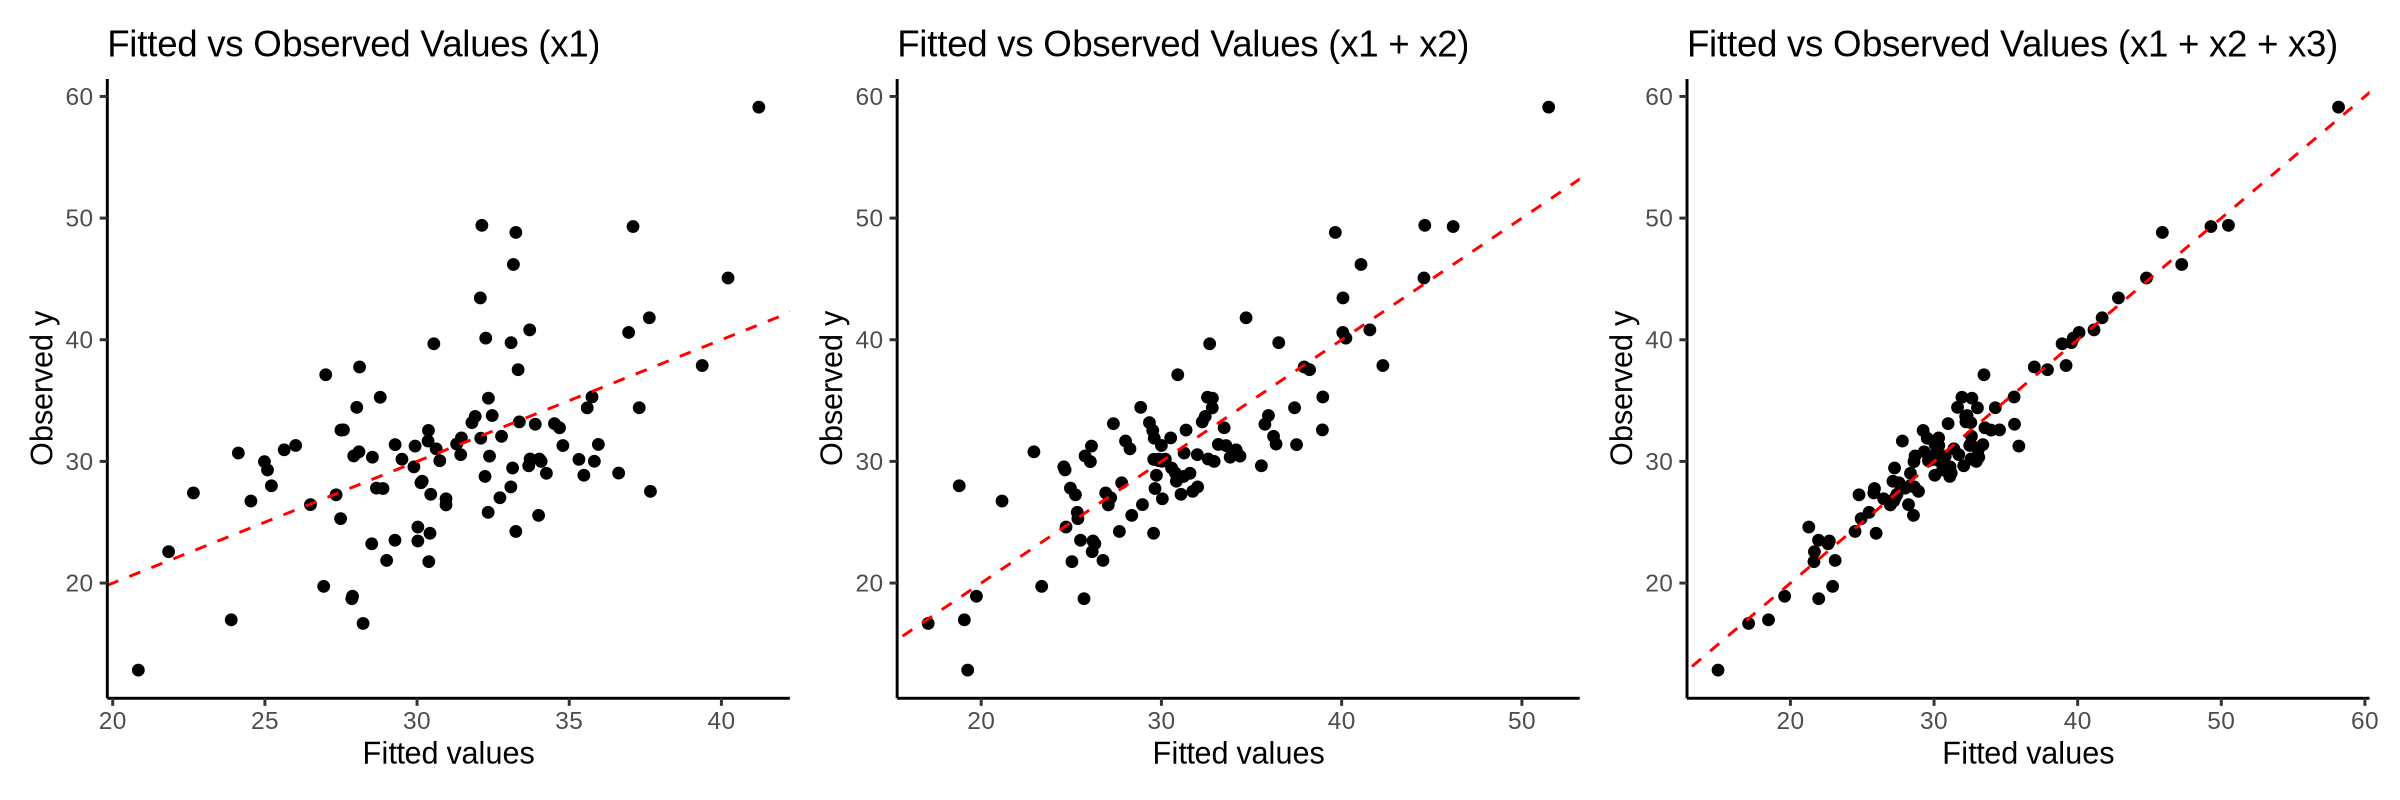

In [6]:
options(repr.plot.width = 12, repr.plot.height = 4, repr.plot.res = 200)

df$fitted <- fitted(model1)
plt1 <- ggplot(df, aes(x = fitted, y = y)) +
    geom_point() +
    geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed") +
    labs(x = "Fitted values", y = "Observed y", title = "Fitted vs Observed Values (x1)") +
    theme_classic()

df$fitted <- fitted(model2)
plt2 <- ggplot(df, aes(x = fitted, y = y)) +
    geom_point() +
    geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed") +
    labs(x = "Fitted values", y = "Observed y", title = "Fitted vs Observed Values (x1 + x2)") +
    theme_classic()

df$fitted <- fitted(model3)
plt3 <- ggplot(df, aes(x = fitted, y = y)) +
    geom_point() +
    geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed") +
    labs(x = "Fitted values", y = "Observed y", title = "Fitted vs Observed Values (x1 + x2 + x3)") +
    theme_classic()

plt1 + plt2 + plt3


- If the fitted values correlate well with the observed values, the model is more likely to not omit important variables


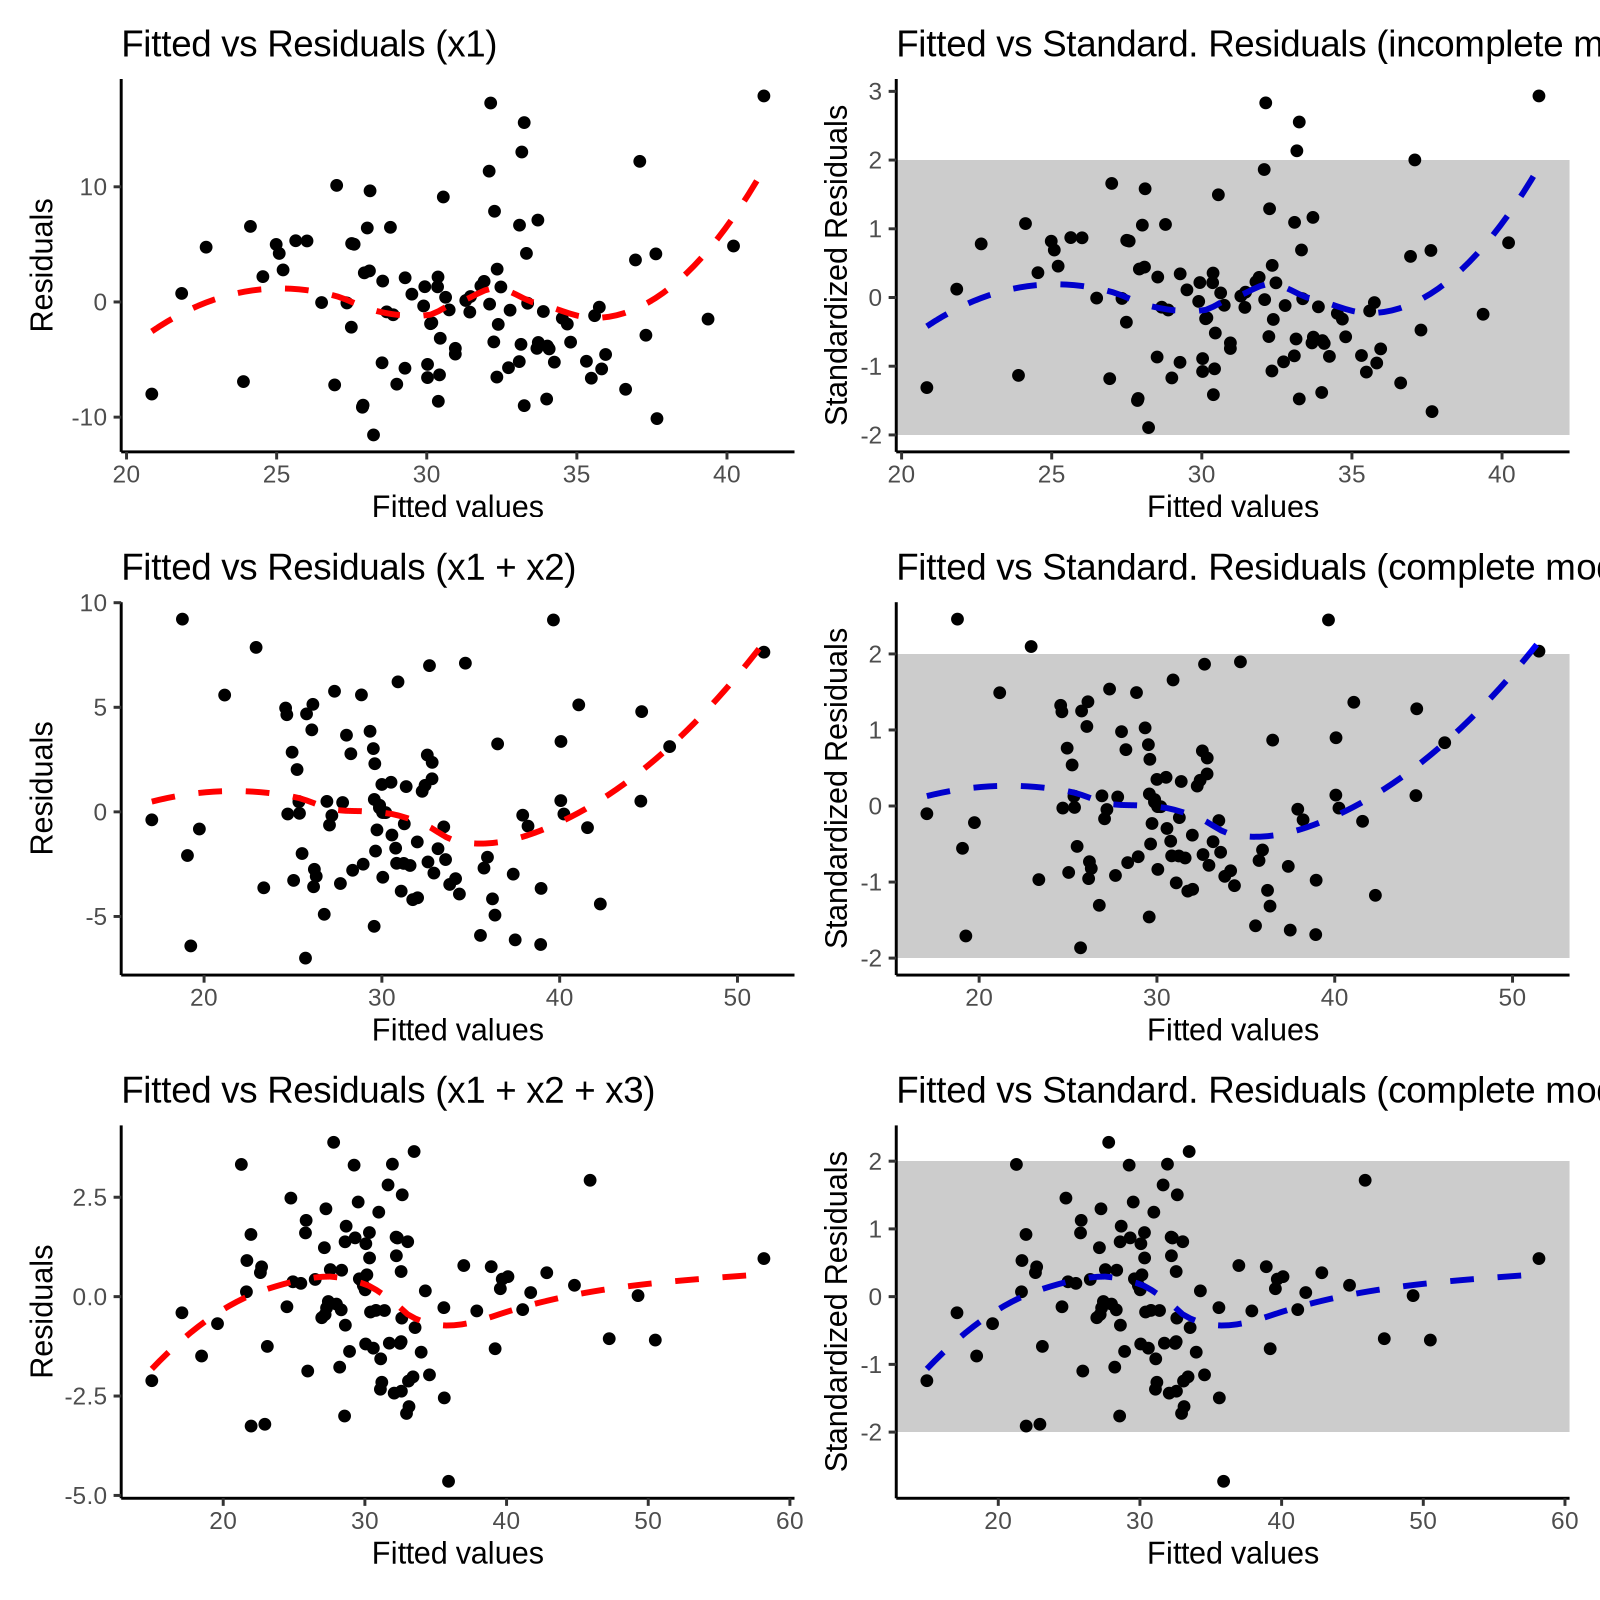

In [7]:
options(repr.plot.width = 8, repr.plot.height = 8, repr.plot.res = 200)

df$fitted <- fitted(model1)
df$residuals <- residuals(model1)
df$residuals_standardized <- residuals(model1) / sd(residuals(model1))

plt1 <- ggplot(df, aes(x = fitted, y = residuals)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "red", linetype = "dashed") +
    labs(x = "Fitted values", y = "Residuals", title = "Fitted vs Residuals (x1)") +
    theme_classic()

plt2 <- ggplot(df, aes(x = fitted, y = residuals_standardized)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "blue", linetype = "dashed") +
    annotate("rect", xmin = -Inf, xmax = Inf, ymin = -2, ymax = 2, alpha = 0.2, fill = "black") +
    labs(x = "Fitted values", y = "Standardized Residuals", title = "Fitted vs Standard. Residuals (incomplete model)") +
    theme_classic()

df$fitted <- fitted(model2)
df$residuals <- residuals(model2)
df$residuals_standardized <- residuals(model2) / sd(residuals(model2))

plt3 <- ggplot(df, aes(x = fitted, y = residuals)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "red", linetype = "dashed") +
    labs(x = "Fitted values", y = "Residuals", title = "Fitted vs Residuals (x1 + x2)") +
    theme_classic()

plt4 <- ggplot(df, aes(x = fitted, y = residuals_standardized)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "blue", linetype = "dashed") +
    annotate("rect", xmin = -Inf, xmax = Inf, ymin = -2, ymax = 2, alpha = 0.2, fill = "black") +
    labs(x = "Fitted values", y = "Standardized Residuals", title = "Fitted vs Standard. Residuals (complete model)") +
    theme_classic()


df$fitted <- fitted(model3)
df$residuals <- residuals(model3)
df$residuals_standardized <- residuals(model3) / sd(residuals(model3))

plt5 <- ggplot(df, aes(x = fitted, y = residuals)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "red", linetype = "dashed") +
    labs(x = "Fitted values", y = "Residuals", title = "Fitted vs Residuals (x1 + x2 + x3)") +
    theme_classic()

plt6 <- ggplot(df, aes(x = fitted, y = residuals_standardized)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "blue", linetype = "dashed") +
    annotate("rect", xmin = -Inf, xmax = Inf, ymin = -2, ymax = 2, alpha = 0.2, fill = "black") +
    labs(x = "Fitted values", y = "Standardized Residuals", title = "Fitted vs Standard. Residuals (complete model)") +
    theme_classic()

(plt1 + plt2) / (plt3 + plt4) / (plt5 + plt6)


- The residuals are much smaller overall in the complete model, and the lowess follows closer to 0
- but without knowing the real data it would be difficult to say if the incomplete model explains most of the effect just by those plots


Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -0.02”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 1.02”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  0”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“There are other near singularities as well. 1”


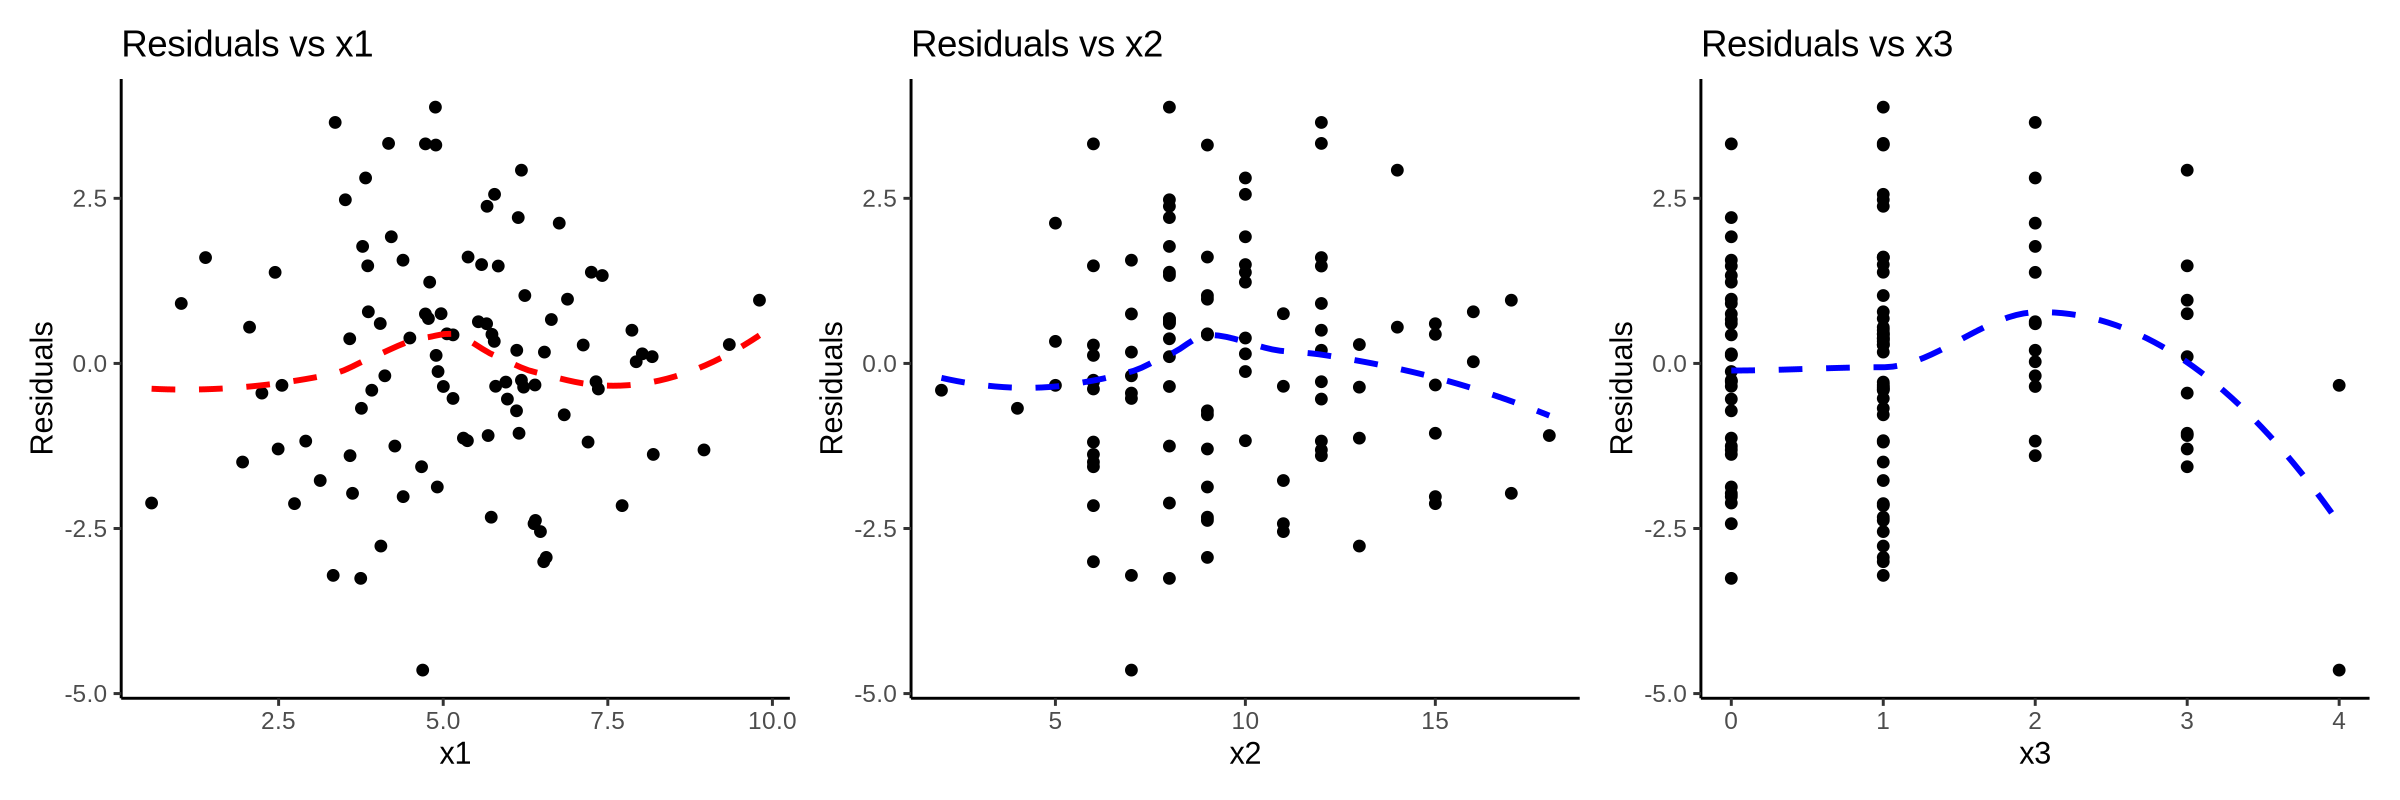

In [8]:
options(repr.plot.width = 12, repr.plot.height = 4, repr.plot.res = 200)

plt_x1 <- ggplot(df, aes(x = x1, y = residuals)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "red", linetype = "dashed") +
    labs(x = "x1", y = "Residuals", title = "Residuals vs x1") +
    theme_classic()

plt_x2 <- ggplot(df, aes(x = x2, y = residuals)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "blue", linetype = "dashed") +
    labs(x = "x2", y = "Residuals", title = "Residuals vs x2") +
    theme_classic()

plt_x3 <- ggplot(df, aes(x = x3, y = residuals)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "blue", linetype = "dashed") +
    labs(x = "x3", y = "Residuals", title = "Residuals vs x3") +
    theme_classic()

plt_x1 + plt_x2 + plt_x3


## Transformations

This assumption implies that we have taken all possible non-linearities into account. If, for example, instead of using a multiplicative model, we apply an additive one, the estimates of parameters and the point forecasts might be biased. This is because the model will produce linear trajectory of the forecast, when a non-linear one is needed. The diagnostics of this assumption is similar to the diagnostics shown above for the omitted variables: construct actuals vs fitted and residuals vs fitted in order to see if there are any patterns in the plots.


In [36]:
set.seed(11)
n <- 100
x1 <- rnorm(n, mean = 8, sd = 2)
x2 <- rnorm(n, mean = 10, sd = 3)
x3 <- rnorm(n, mean = 30, sd = 3)
# x3 <- rpois(n, lambda = 1)
y <- 3 + (2 * x1) * (1.5 * x2) * (3 * x3) * exp(rnorm(n, mean = 0, sd = 0.3)) # The observed data is a non-linear function of the 2 variables x1 and x2

df <- data.frame(x1 = x1, x2 = x2, x3 = x3, y = y)
head(df)
dim(df)


,x1,x2,x3,y
,<dbl>,<dbl>,<dbl>,<dbl>
1,6.817938,8.674994,31.97484,10694.03
2,8.053189,10.730916,34.95600,21874.79
3,4.966894,11.790343,26.23240,10886.17
4,5.274693,9.639878,32.64312,27762.62
5,10.356978,3.790770,32.22765,21061.44
6,6.131697,11.756877,30.02622,24666.22


[1] 100   4

In [37]:
model1 <- lm(formula = y ~ x1 + x2 + x3, data = df)
summary(model1)



Call:
lm(formula = y ~ x1 + x2 + x3, data = df)

Residuals:
     Min       1Q   Median       3Q      Max 
-13999.4  -4375.4   -421.7   4319.6  16030.0 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -38918.5     7582.5  -5.133 1.49e-06 ***
x1            2663.8      359.0   7.421 4.68e-11 ***
x2            2298.4      223.5  10.284  < 2e-16 ***
x3             567.3      226.5   2.504    0.014 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6529 on 96 degrees of freedom
Multiple R-squared:  0.6448,	Adjusted R-squared:  0.6337 
F-statistic: 58.09 on 3 and 96 DF,  p-value: < 2.2e-16


In [38]:
model2 <- lm(formula = log(y) ~ x1 + x2 + x3, data = df)
summary(model2)



Call:
lm(formula = log(y) ~ x1 + x2 + x3, data = df)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.75329 -0.17317 -0.01528  0.22420  0.70910 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  7.09926    0.37344  19.011  < 2e-16 ***
x1           0.12298    0.01768   6.956 4.27e-10 ***
x2           0.11260    0.01101  10.229  < 2e-16 ***
x3           0.02270    0.01116   2.035   0.0446 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.3215 on 96 degrees of freedom
Multiple R-squared:  0.6302,	Adjusted R-squared:  0.6186 
F-statistic: 54.52 on 3 and 96 DF,  p-value: < 2.2e-16


In [39]:
model3 <- lm(log(y) ~ log(x1) + log(x2) + log(x3), data = df)
summary(model3)



Call:
lm(formula = log(y) ~ log(x1) + log(x2) + log(x3), data = df)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.76977 -0.18454  0.00263  0.20176  0.67289 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.82685    1.10783   2.552   0.0123 *  
log(x1)      1.01606    0.12672   8.018  2.6e-12 ***
log(x2)      1.04383    0.09441  11.057  < 2e-16 ***
log(x3)      0.77438    0.31281   2.476   0.0151 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.305 on 96 degrees of freedom
Multiple R-squared:  0.6672,	Adjusted R-squared:  0.6568 
F-statistic: 64.14 on 3 and 96 DF,  p-value: < 2.2e-16


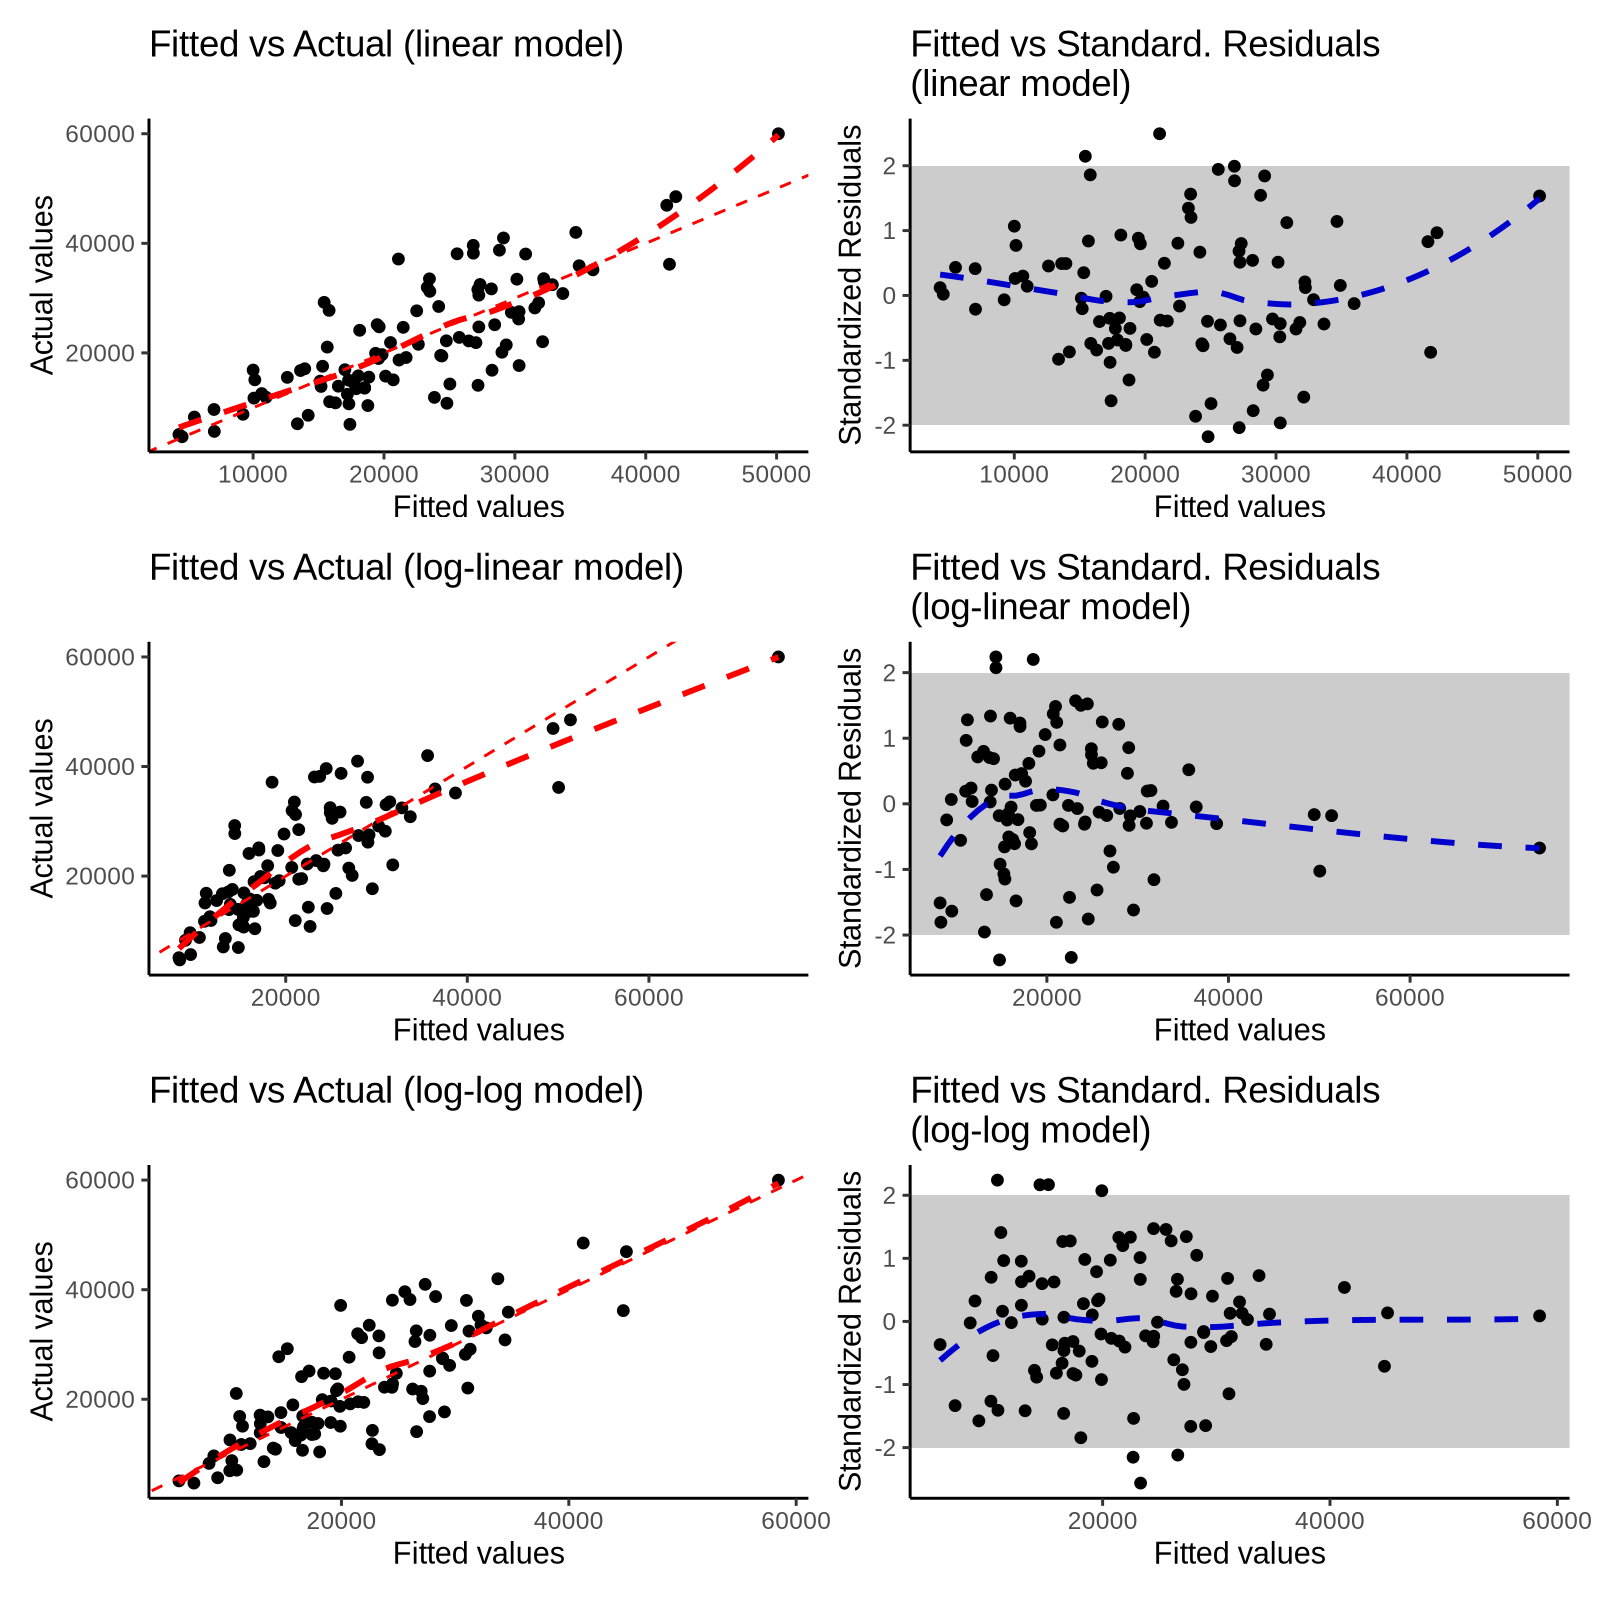

In [40]:
options(repr.plot.width = 8, repr.plot.height = 8, repr.plot.res = 200)

df$fitted <- fitted(model1)
df$residuals <- residuals(model1)
df$residuals_standardized <- residuals(model1) / sd(residuals(model1))

plt1 <- ggplot(df, aes(x = fitted, y = y)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "red", linetype = "dashed") +
    geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed") +
    labs(x = "Fitted values", y = "Actual values", title = "Fitted vs Actual (linear model)") +
    theme_classic()

plt2 <- ggplot(df, aes(x = fitted, y = residuals_standardized)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "blue", linetype = "dashed") +
    annotate("rect", xmin = -Inf, xmax = Inf, ymin = -2, ymax = 2, alpha = 0.2, fill = "black") +
    labs(x = "Fitted values", y = "Standardized Residuals", title = "Fitted vs Standard. Residuals\n(linear model)") +
    theme_classic()

df$fitted <- exp(fitted(model2))
df$residuals <- residuals(model2)
df$residuals_standardized <- residuals(model2) / sd(residuals(model2))

plt3 <- ggplot(df, aes(x = fitted, y = y)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "red", linetype = "dashed") +
    geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed") +
    labs(x = "Fitted values", y = "Actual values", title = "Fitted vs Actual (log-linear model)") +
    theme_classic()

plt4 <- ggplot(df, aes(x = fitted, y = residuals_standardized)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "blue", linetype = "dashed") +
    annotate("rect", xmin = -Inf, xmax = Inf, ymin = -2, ymax = 2, alpha = 0.2, fill = "black") +
    labs(x = "Fitted values", y = "Standardized Residuals", title = "Fitted vs Standard. Residuals\n(log-linear model)") +
    theme_classic()


# sigma2 <- summary(model3)$sigma^2
# bias_correction <- exp(sigma2 / 2)
# df$fitted <- exp(fitted(model3)) * bias_correction # this should have fixed the multiplicative error bias, but it is not enough
df$fitted <- exp(fitted(model3))
df$residuals <- residuals(model3)
df$residuals_standardized <- residuals(model3) / sd(residuals(model3))

plt5 <- ggplot(df, aes(x = fitted, y = y)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "red", linetype = "dashed") +
    geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed") +
    labs(x = "Fitted values", y = "Actual values", title = "Fitted vs Actual (log-log model)") +
    theme_classic()

plt6 <- ggplot(df, aes(x = fitted, y = residuals_standardized)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "blue", linetype = "dashed") +
    annotate("rect", xmin = -Inf, xmax = Inf, ymin = -2, ymax = 2, alpha = 0.2, fill = "black") +
    labs(x = "Fitted values", y = "Standardized Residuals", title = "Fitted vs Standard. Residuals\n(log-log model)") +
    theme_classic()

(plt1 + plt2) / (plt3 + plt4) / (plt5 + plt6)


- both the log-log is a better model:
  - better residual standard deviation
  - residuals are better spread through the fitted values range (linear model 's residuals spread at higher fitted values)


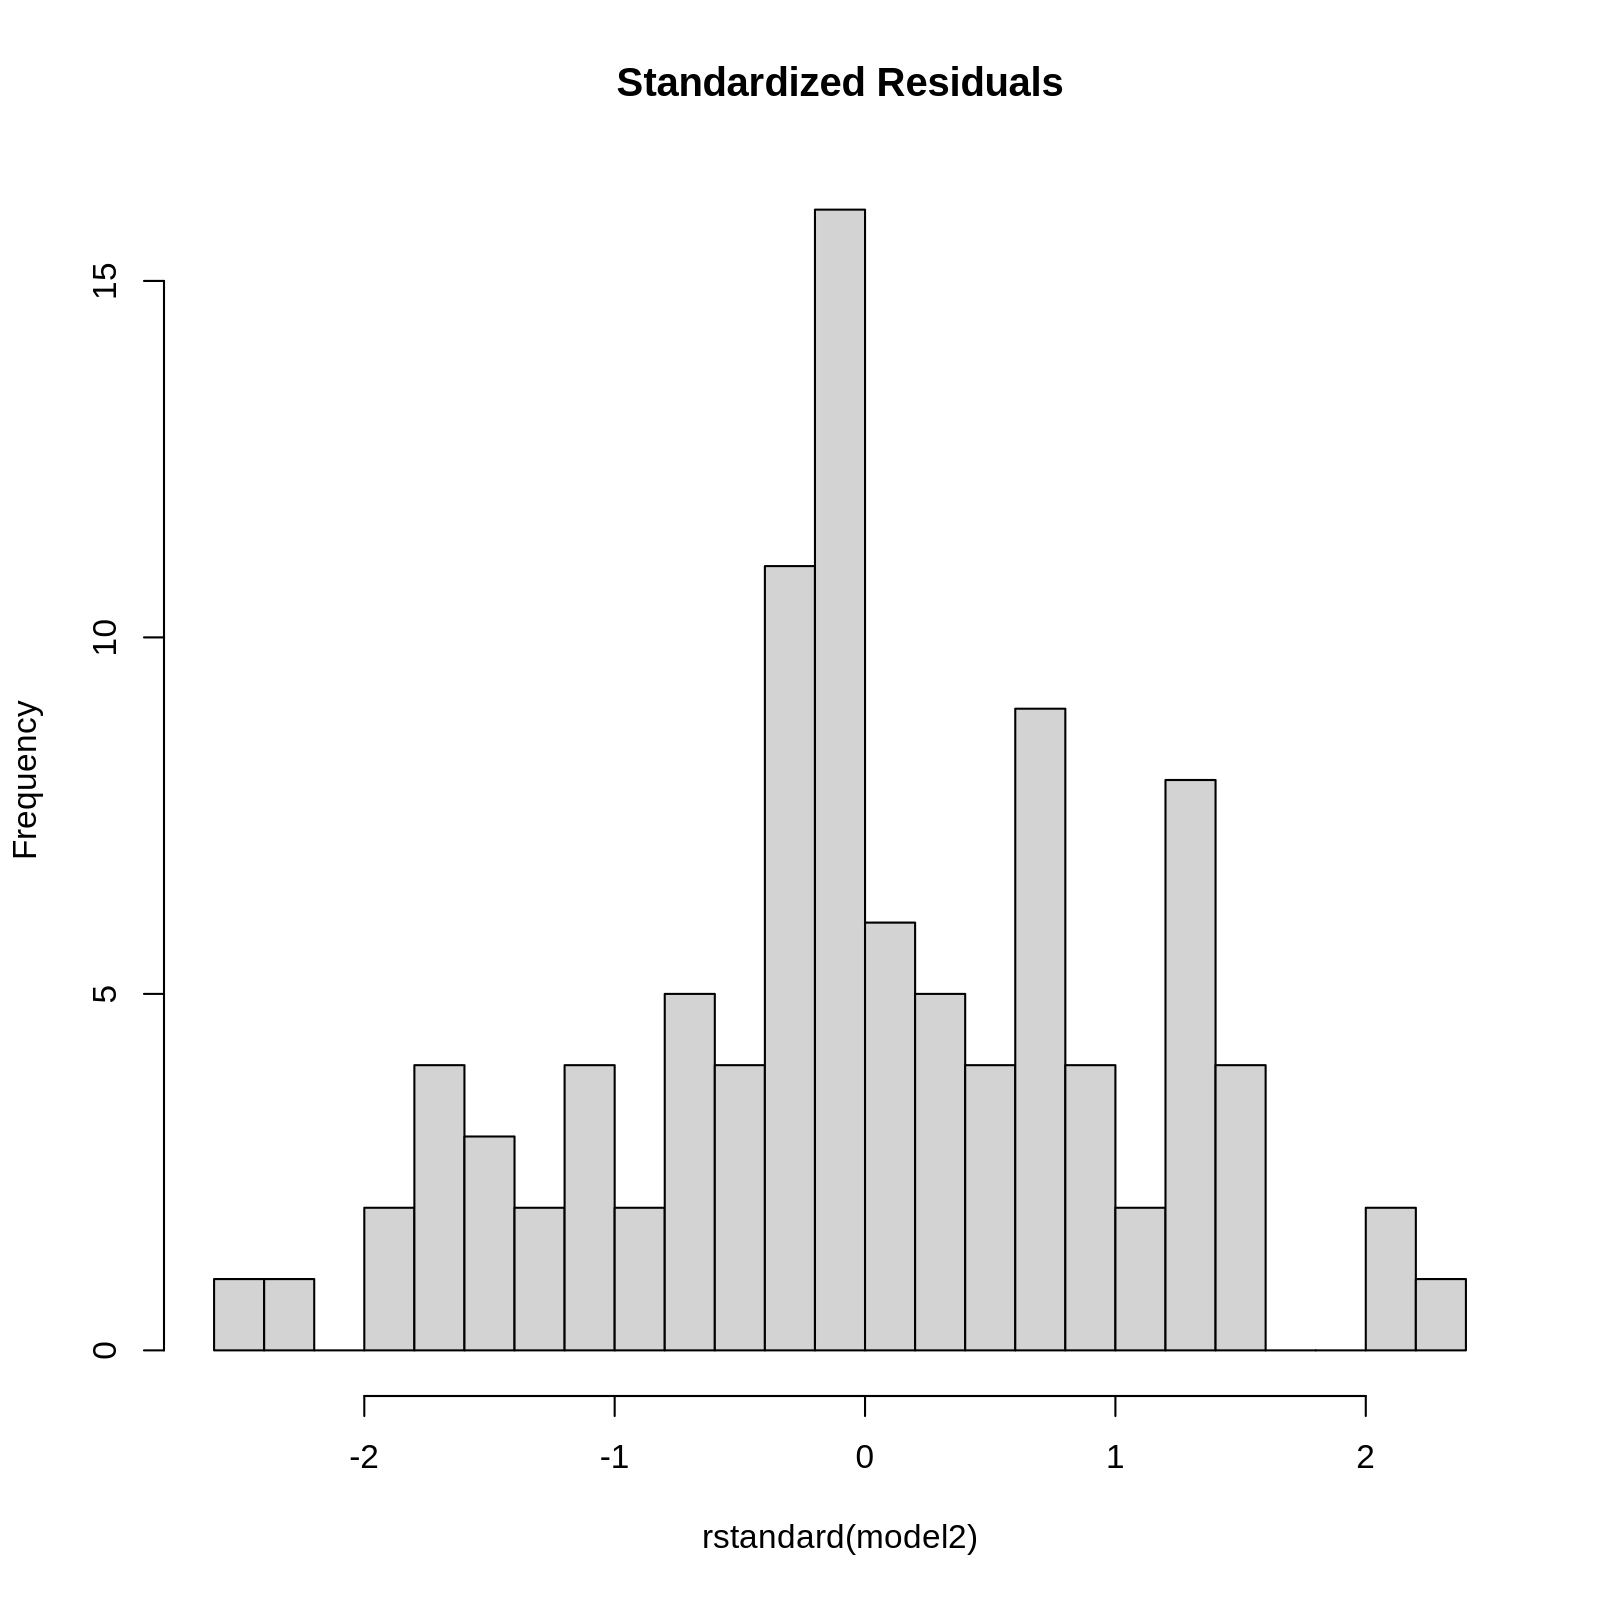

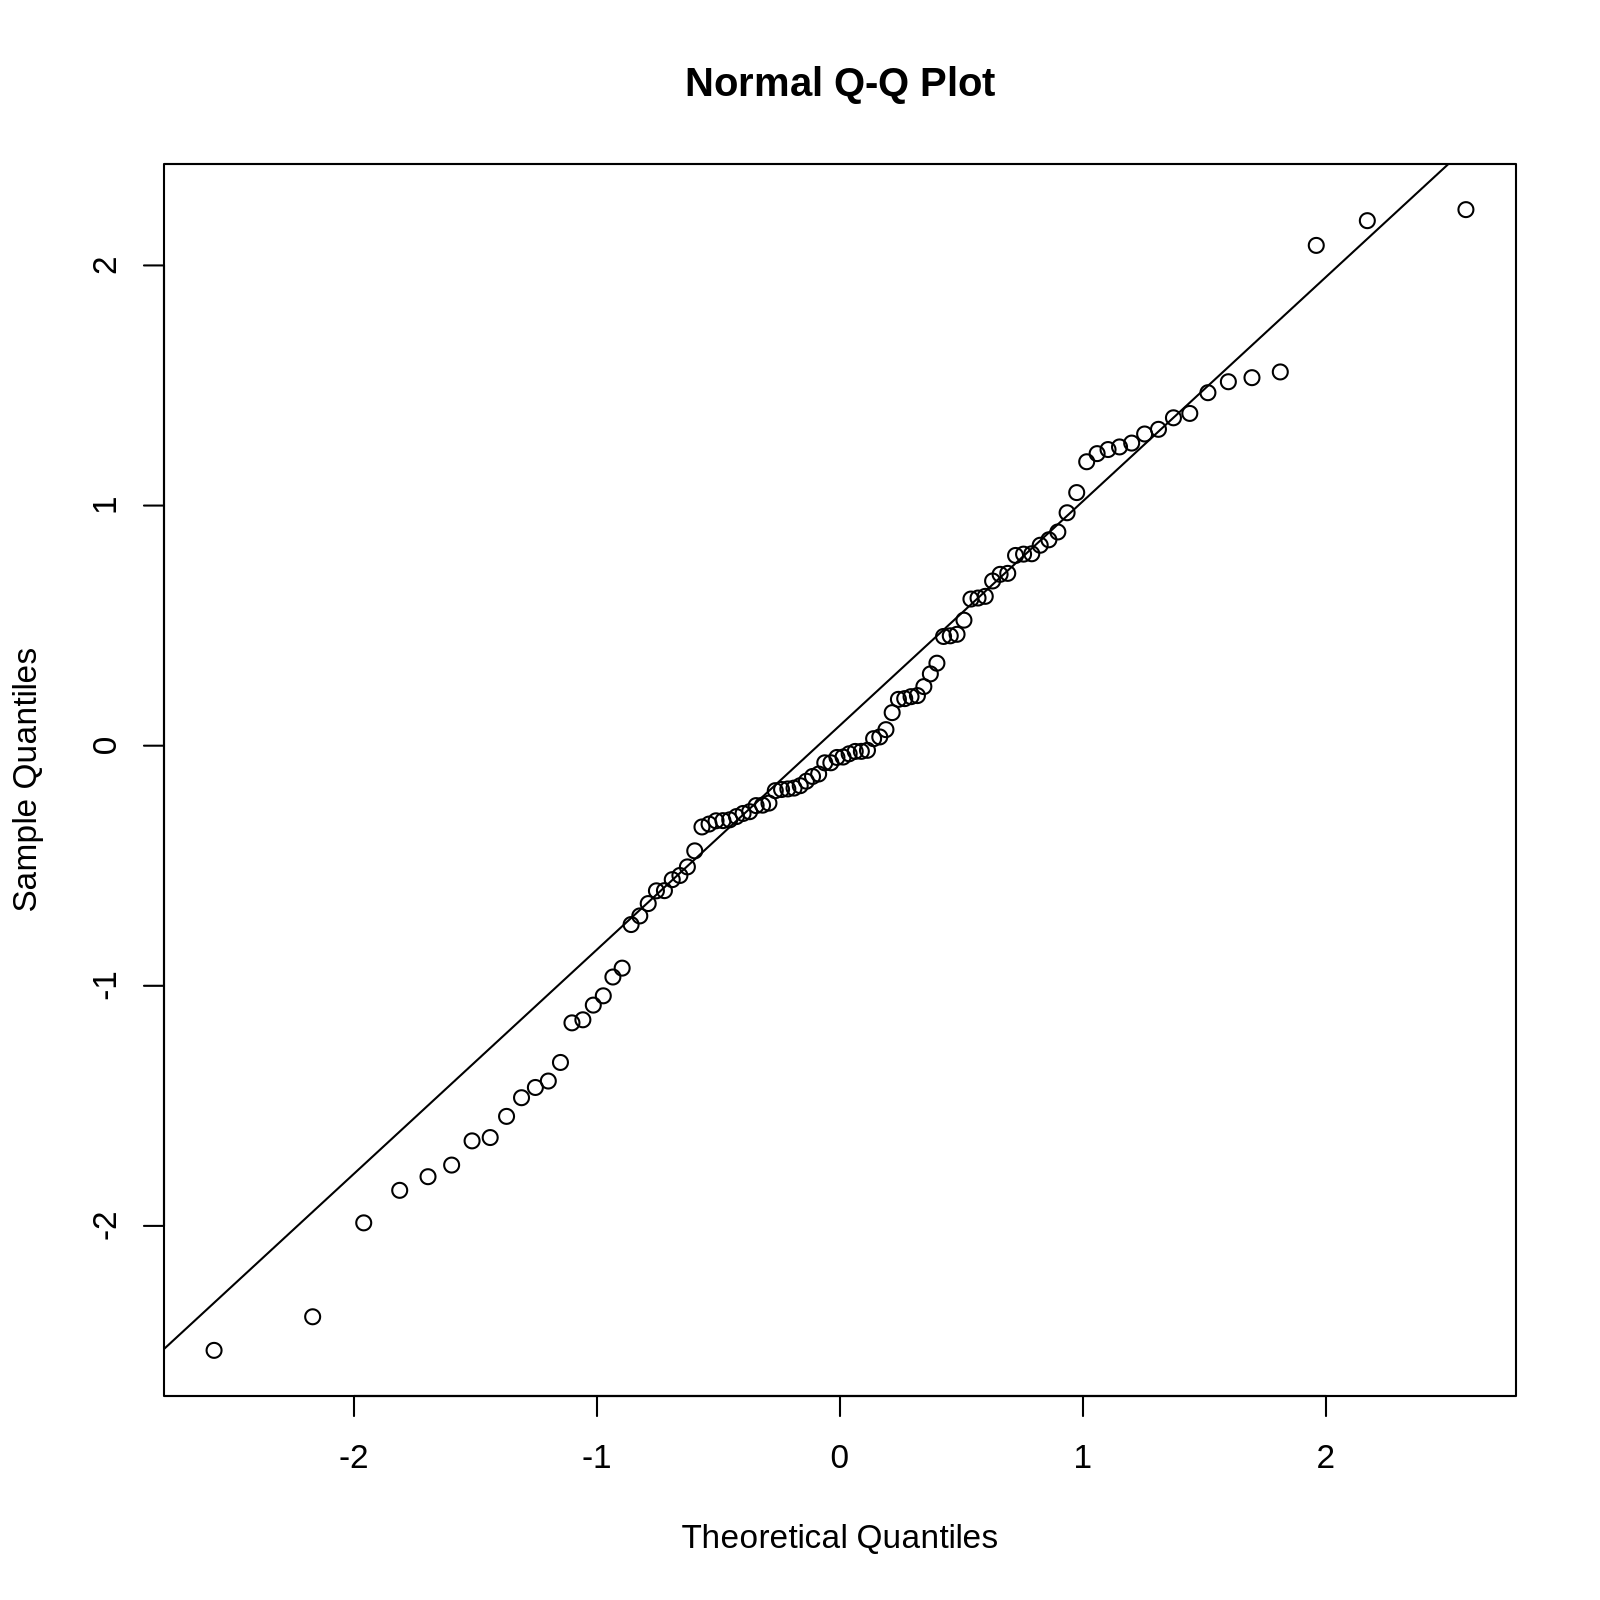

In [41]:
hist(rstandard(model2), breaks = 20, main = "Standardized Residuals")
qqnorm(rstandard(model2))
qqline(rstandard(model2))


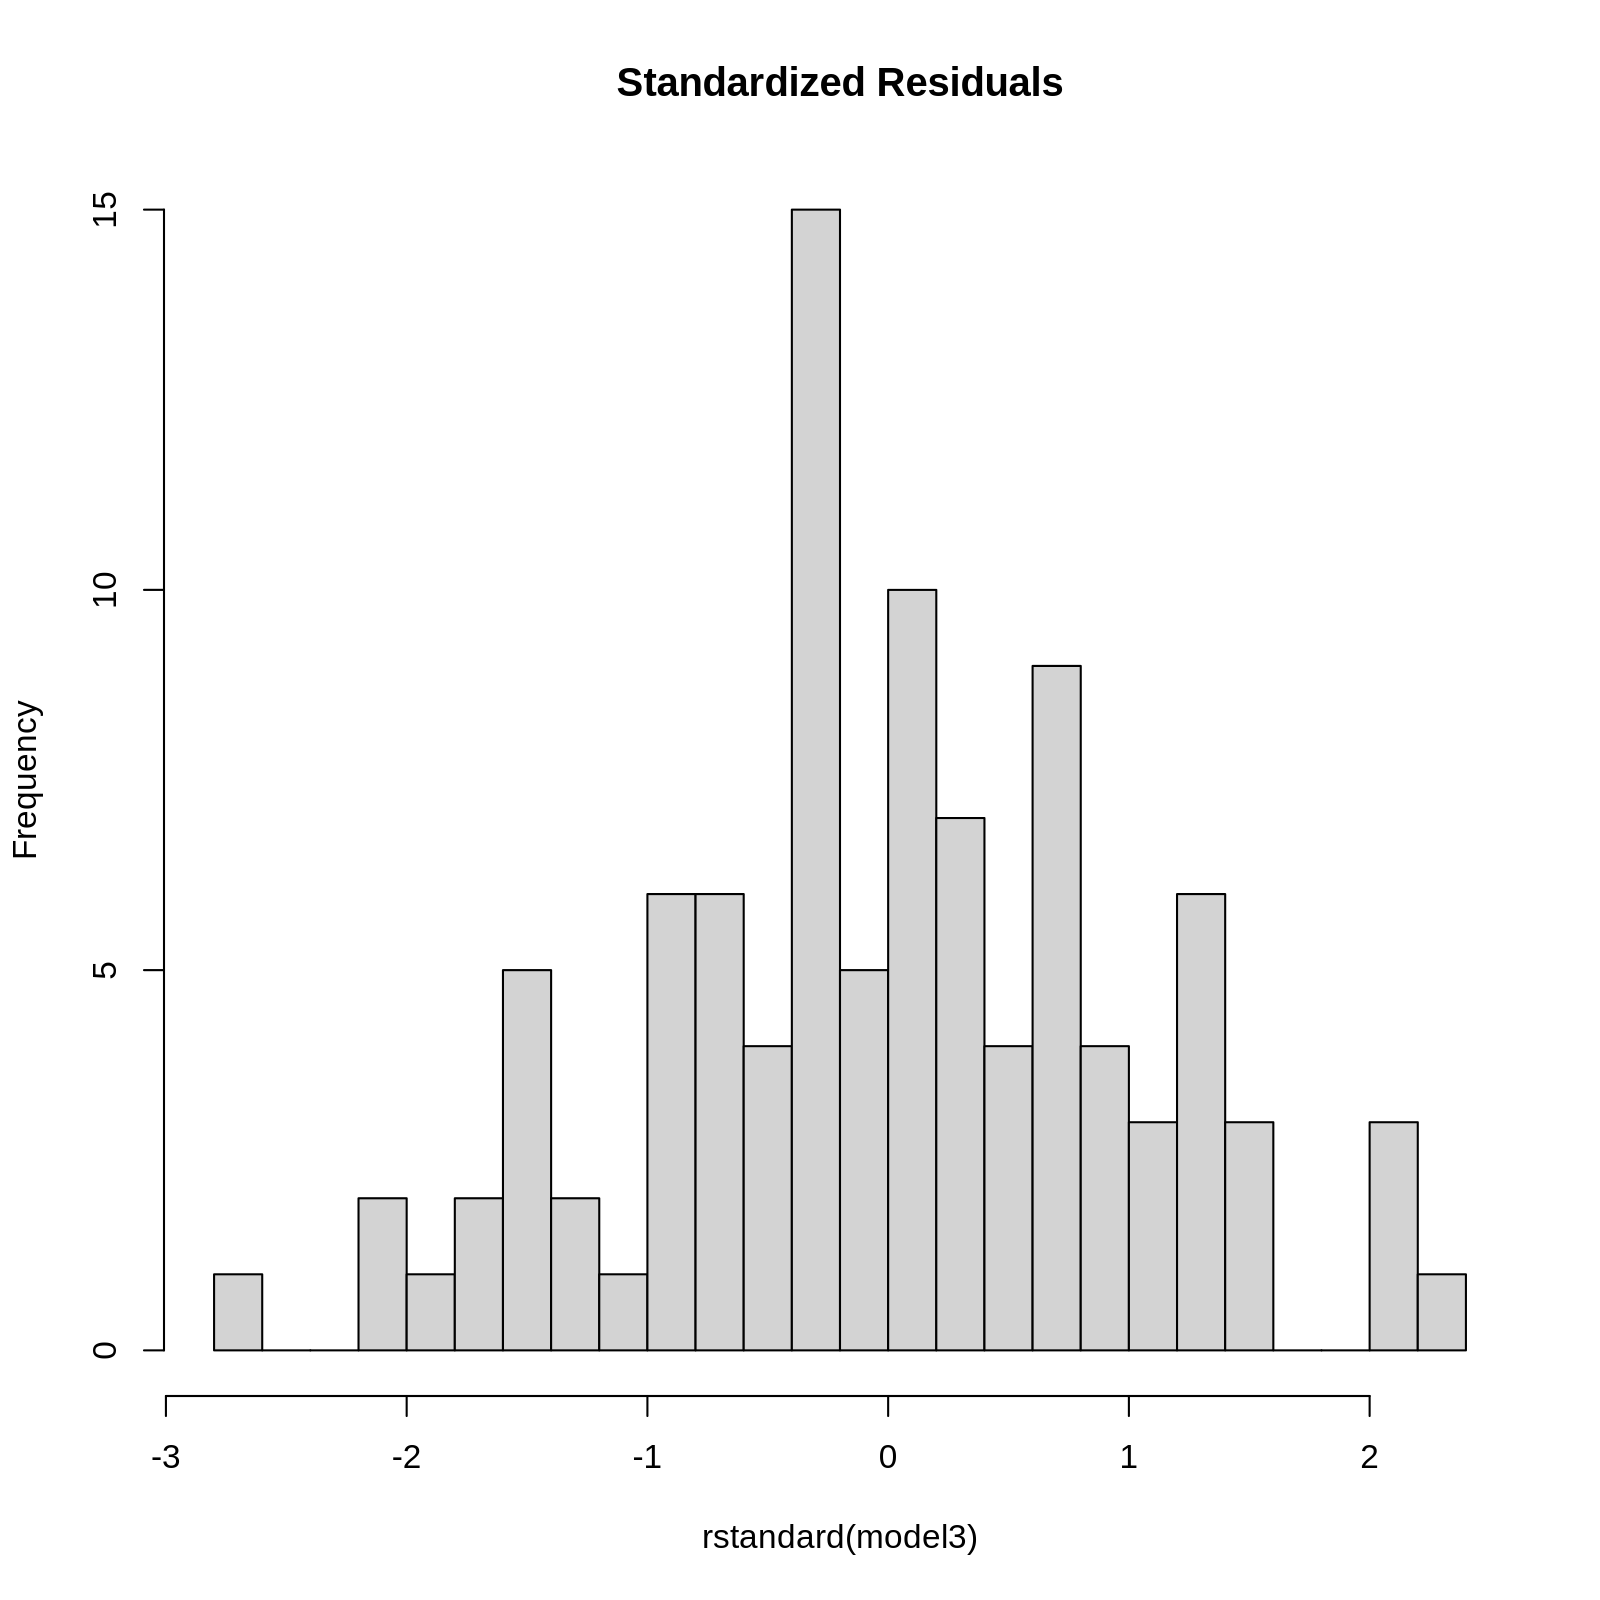

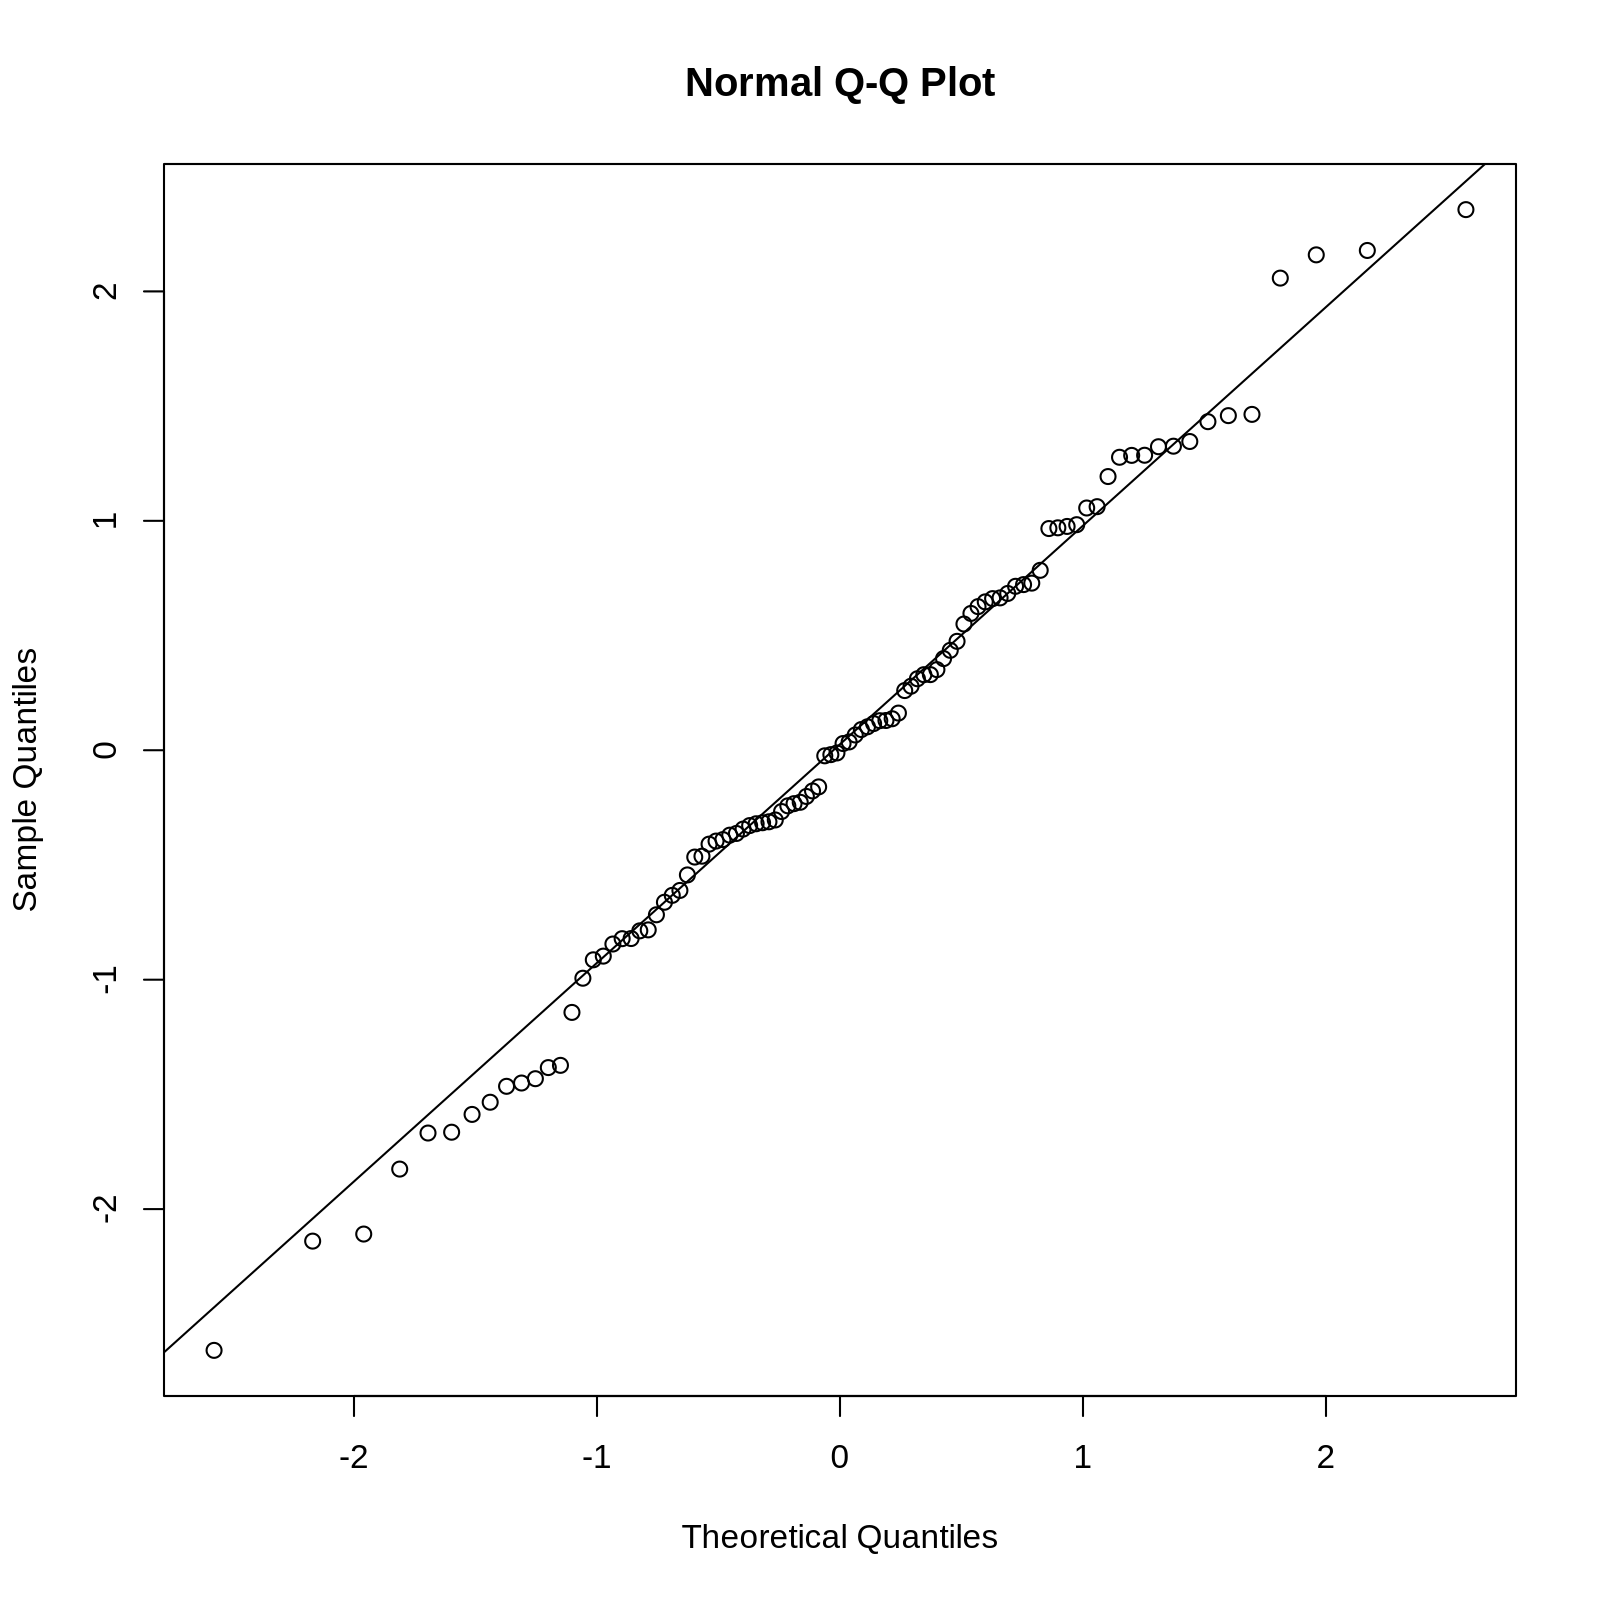

In [42]:
hist(rstandard(model3), breaks = 20, main = "Standardized Residuals")
qqnorm(rstandard(model3))
qqline(rstandard(model3))


- The model 3 small amount of values below -2 in the st.residuals are probably just expected variation


## Outliers

In a way, this assumption is similar to the first one with omitted variables. The presence of outliers might mean that we have missed some important information, implying that the estimates of parameters and forecasts would be biased. There can be other reasons for outliers as well. For example, we might be using a wrong distributional assumption. If so, this would imply that the prediction interval from the model is narrower than necessary. The diagnostics of outliers comes to producing standardised residuals vs fitted, to studentised vs fitted and to Cook’s distance plot.


In [50]:
set.seed(1)
n <- 100
x1 <- rnorm(n, mean = 5, sd = 2)
x2 <- rpois(n, lambda = 10)
x3 <- rpois(n, lambda = 1)
y <- 3 + (2 * x1) + (1.5 * x2) + (3 * x3) + rnorm(n, mean = 0, sd = 2) # The observed data is a function of the 2 variables x1 and x2

df <- data.frame(x1 = x1, x2 = x2, x3 = x3, y = y)
df$y[1] <- 50

head(df)
dim(df)


,x1,x2,x3,y
,<dbl>,<int>,<int>,<dbl>
1,3.747092,8,0,50.00000
2,5.367287,10,1,30.55495
3,3.328743,7,1,19.72848
4,8.190562,6,0,27.53913
5,5.659016,15,2,43.43831
6,3.359063,12,2,37.12327


[1] 100   4

In [51]:
model1 <- lm(formula = y ~ x1 + x2 + x3, data = df)
summary(model1)



Call:
lm(formula = y ~ x1 + x2 + x3, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.1104 -1.3942 -0.2842  0.8725 27.0477 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   4.1324     1.4207   2.909  0.00451 ** 
x1            2.0495     0.1846  11.101  < 2e-16 ***
x2            1.3925     0.1028  13.546  < 2e-16 ***
x3            2.9704     0.3276   9.066 1.51e-14 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.278 on 96 degrees of freedom
Multiple R-squared:  0.8102,	Adjusted R-squared:  0.8042 
F-statistic: 136.6 on 3 and 96 DF,  p-value: < 2.2e-16


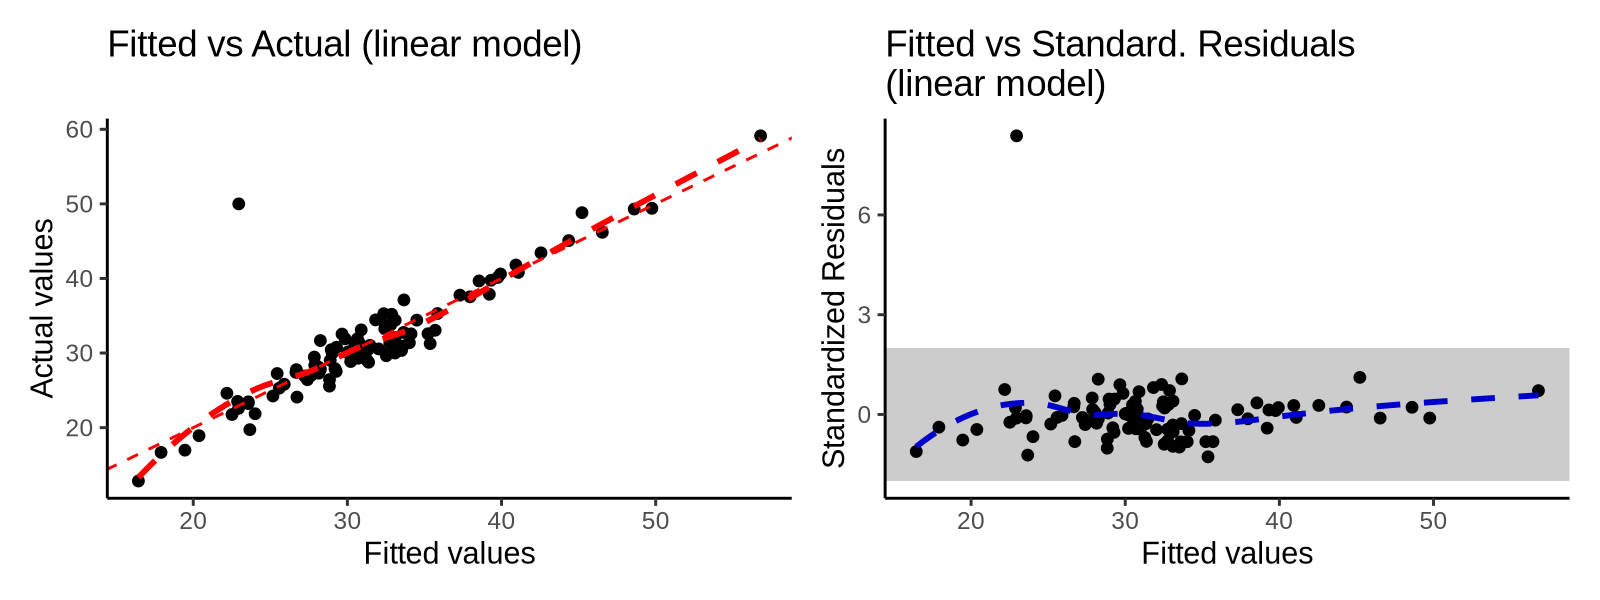

In [52]:
options(repr.plot.width = 8, repr.plot.height = 3, repr.plot.res = 200)

df$fitted <- fitted(model1)
df$residuals <- residuals(model1)
df$residuals_standardized <- residuals(model1) / sd(residuals(model1))

plt1 <- ggplot(df, aes(x = fitted, y = y)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "red", linetype = "dashed") +
    geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed") +
    labs(x = "Fitted values", y = "Actual values", title = "Fitted vs Actual (linear model)") +
    theme_classic()

plt2 <- ggplot(df, aes(x = fitted, y = residuals_standardized)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "blue", linetype = "dashed") +
    annotate("rect", xmin = -Inf, xmax = Inf, ymin = -2, ymax = 2, alpha = 0.2, fill = "black") +
    labs(x = "Fitted values", y = "Standardized Residuals", title = "Fitted vs Standard. Residuals\n(linear model)") +
    theme_classic()

(plt1 + plt2)


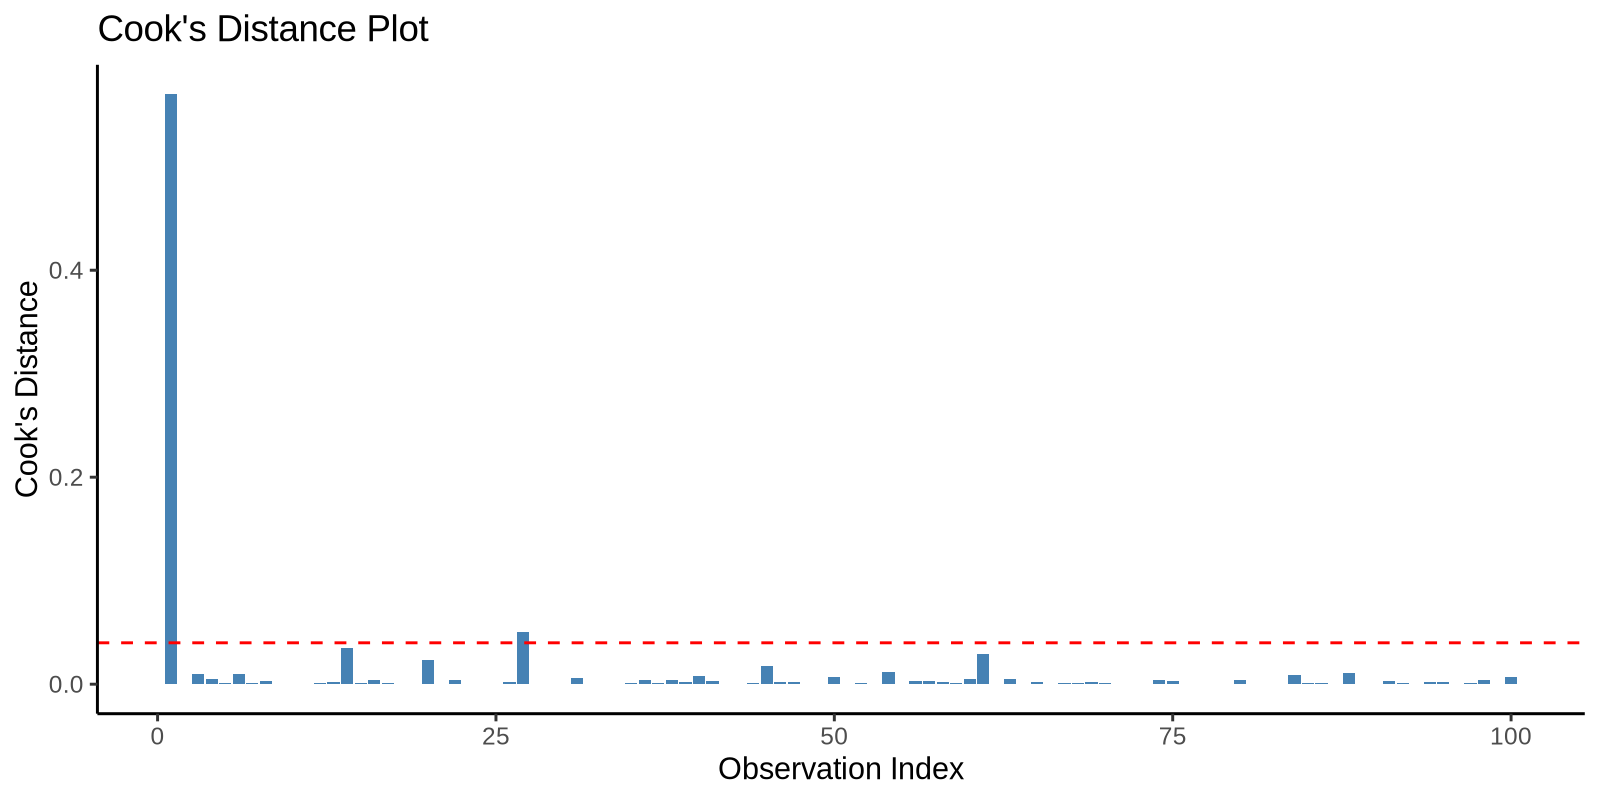

In [53]:
options(repr.plot.width = 8, repr.plot.height = 4, repr.plot.res = 200)

cooks_d <- cooks.distance(model1)
df$cooks_d <- cooks_d

ggplot(df, aes(x = seq_along(cooks_d), y = cooks_d)) +
    geom_bar(stat = "identity", fill = "steelblue") +
    geom_hline(yintercept = 4 / nrow(df), color = "red", linetype = "dashed") +
    labs(x = "Observation Index", y = "Cook's Distance", title = "Cook's Distance Plot") +
    theme_classic()


- The Cook's distance tells us if removing each point has a big effect on the model fitting well
- Larger distances means that removing that data point improves the model a lot
- If removal of just one point makes a big difference then we can conclude that this point is somehow an outlier


In [54]:
# Number of parameters (including intercept)
p <- length(coef(model1))

# Residuals
r <- residuals(model1)

# Estimated variance of residuals
sigma2 <- summary(model1)$sigma^2

# Hat values (leverage)
h <- hatvalues(model1)

# Cook's distance by hand
cooks_d_hand <- (r^2 / (p * sigma2)) * (h / (1 - h)^2)

# Compare with built-in
all.equal(cooks_d_hand, cooks.distance(model1))


[1] TRUE

# Residuals are i.i.d.


## Homoscedastic residuals

In general, we assume that the variance of residuals is constant. If this is violated, then we say that there is a heteroscedasticity in the model. This means that with a change of a variable, the variance of the residuals will change as well. If the model neglects this, then typically the estimates of parameters become inefficient and prediction intervals are wrong: they are wider than needed in some cases (e.g.m when the volume of data is low) and narrower than needed in the other ones (e.g. on high volume data).

Typically, this assumption will be violated if the model is not specified correctly. The classic example is the income versus expenditure on meals for different families. If the income is low, then there are not many options for buying, and the variability of expenses would be low. However, with the increase of income, the mean expenditures and their variability would increase because there are more options of what to buy, including both cheap and expensive products. If we constructed a basic linear model on such data, then it would violate the assumption of homoscedasticity and, as a result, will have issues. But arguably, this would typically appear because of the misspecification of the model. For example, taking logarithms might resolve the issue in many cases, implying that the effect of one variable on the other should be multiplicative rather than additive. Alternatively, dividing variables by some other variable might (e.g. working with expenses per family member, not per family) resolve the problem as well. Unfortunately, the transformations are not the panacea, so in some cases, the analyst would need to construct a model, taking the changing variance into account (e.g. GARCH or GAMLSS models).


In [66]:
set.seed(111)
n <- 100
x1 <- rnorm(n, mean = 8, sd = 2)
x2 <- rnorm(n, mean = 10, sd = 3)
x3 <- rnorm(n, mean = 30, sd = 3)
y <- 3 + (2 * x1) * (1.5 * x2) * (3 * x3) * exp(rnorm(n, mean = 0, sd = 0.3)) # The observed data is a non-linear function of the 2 variables x1 and x2

df <- data.frame(x1 = x1, x2 = x2, x3 = x3, y = y)
head(df)
dim(df)


,x1,x2,x3,y
,<dbl>,<dbl>,<dbl>,<dbl>
1,8.470441,11.798859,29.10390,27329.755
2,7.338528,6.519011,28.21939,13553.340
3,7.376752,11.317280,32.48011,22992.143
4,3.395309,10.614561,23.51578,4381.684
5,7.658248,7.902456,27.23687,14145.625
6,8.280556,7.220123,31.55149,20107.756


[1] 100   4

In [67]:
model1 <- lm(formula = y ~ x1 + x2 + x3, data = df)
summary(model1)



Call:
lm(formula = y ~ x1 + x2 + x3, data = df)

Residuals:
   Min     1Q Median     3Q    Max 
-15015  -4885   -210   3726  44280 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -49385.0    10190.5  -4.846 4.83e-06 ***
x1            3504.6      385.9   9.082 1.40e-14 ***
x2            2113.6      269.8   7.833 6.40e-12 ***
x3             758.7      300.2   2.528   0.0131 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 8192 on 96 degrees of freedom
Multiple R-squared:  0.5953,	Adjusted R-squared:  0.5827 
F-statistic: 47.08 on 3 and 96 DF,  p-value: < 2.2e-16


In [68]:
model2 <- lm(formula = log(y) ~ x1 + x2 + x3, data = df)
summary(model2)



Call:
lm(formula = log(y) ~ x1 + x2 + x3, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.6875 -0.1764  0.0392  0.2778  0.9377 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  6.18917    0.63517   9.744 5.27e-16 ***
x1           0.15739    0.02405   6.544 2.93e-09 ***
x2           0.14795    0.01682   8.797 5.70e-14 ***
x3           0.03068    0.01871   1.640    0.104    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.5106 on 96 degrees of freedom
Multiple R-squared:  0.5483,	Adjusted R-squared:  0.5342 
F-statistic: 38.84 on 3 and 96 DF,  p-value: < 2.2e-16


In [69]:
model3 <- lm(log(y) ~ log(x1) + log(x2) + log(x3), data = df)
summary(model3)



Call:
lm(formula = log(y) ~ log(x1) + log(x2) + log(x3), data = df)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.66319 -0.19204  0.02581  0.16828  0.87426 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.27469    1.12850   2.016  0.04663 *  
log(x1)      1.06017    0.09350  11.339  < 2e-16 ***
log(x2)      0.92938    0.04328  21.476  < 2e-16 ***
log(x3)      0.98912    0.32177   3.074  0.00275 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.2876 on 96 degrees of freedom
Multiple R-squared:  0.8566,	Adjusted R-squared:  0.8522 
F-statistic: 191.2 on 3 and 96 DF,  p-value: < 2.2e-16


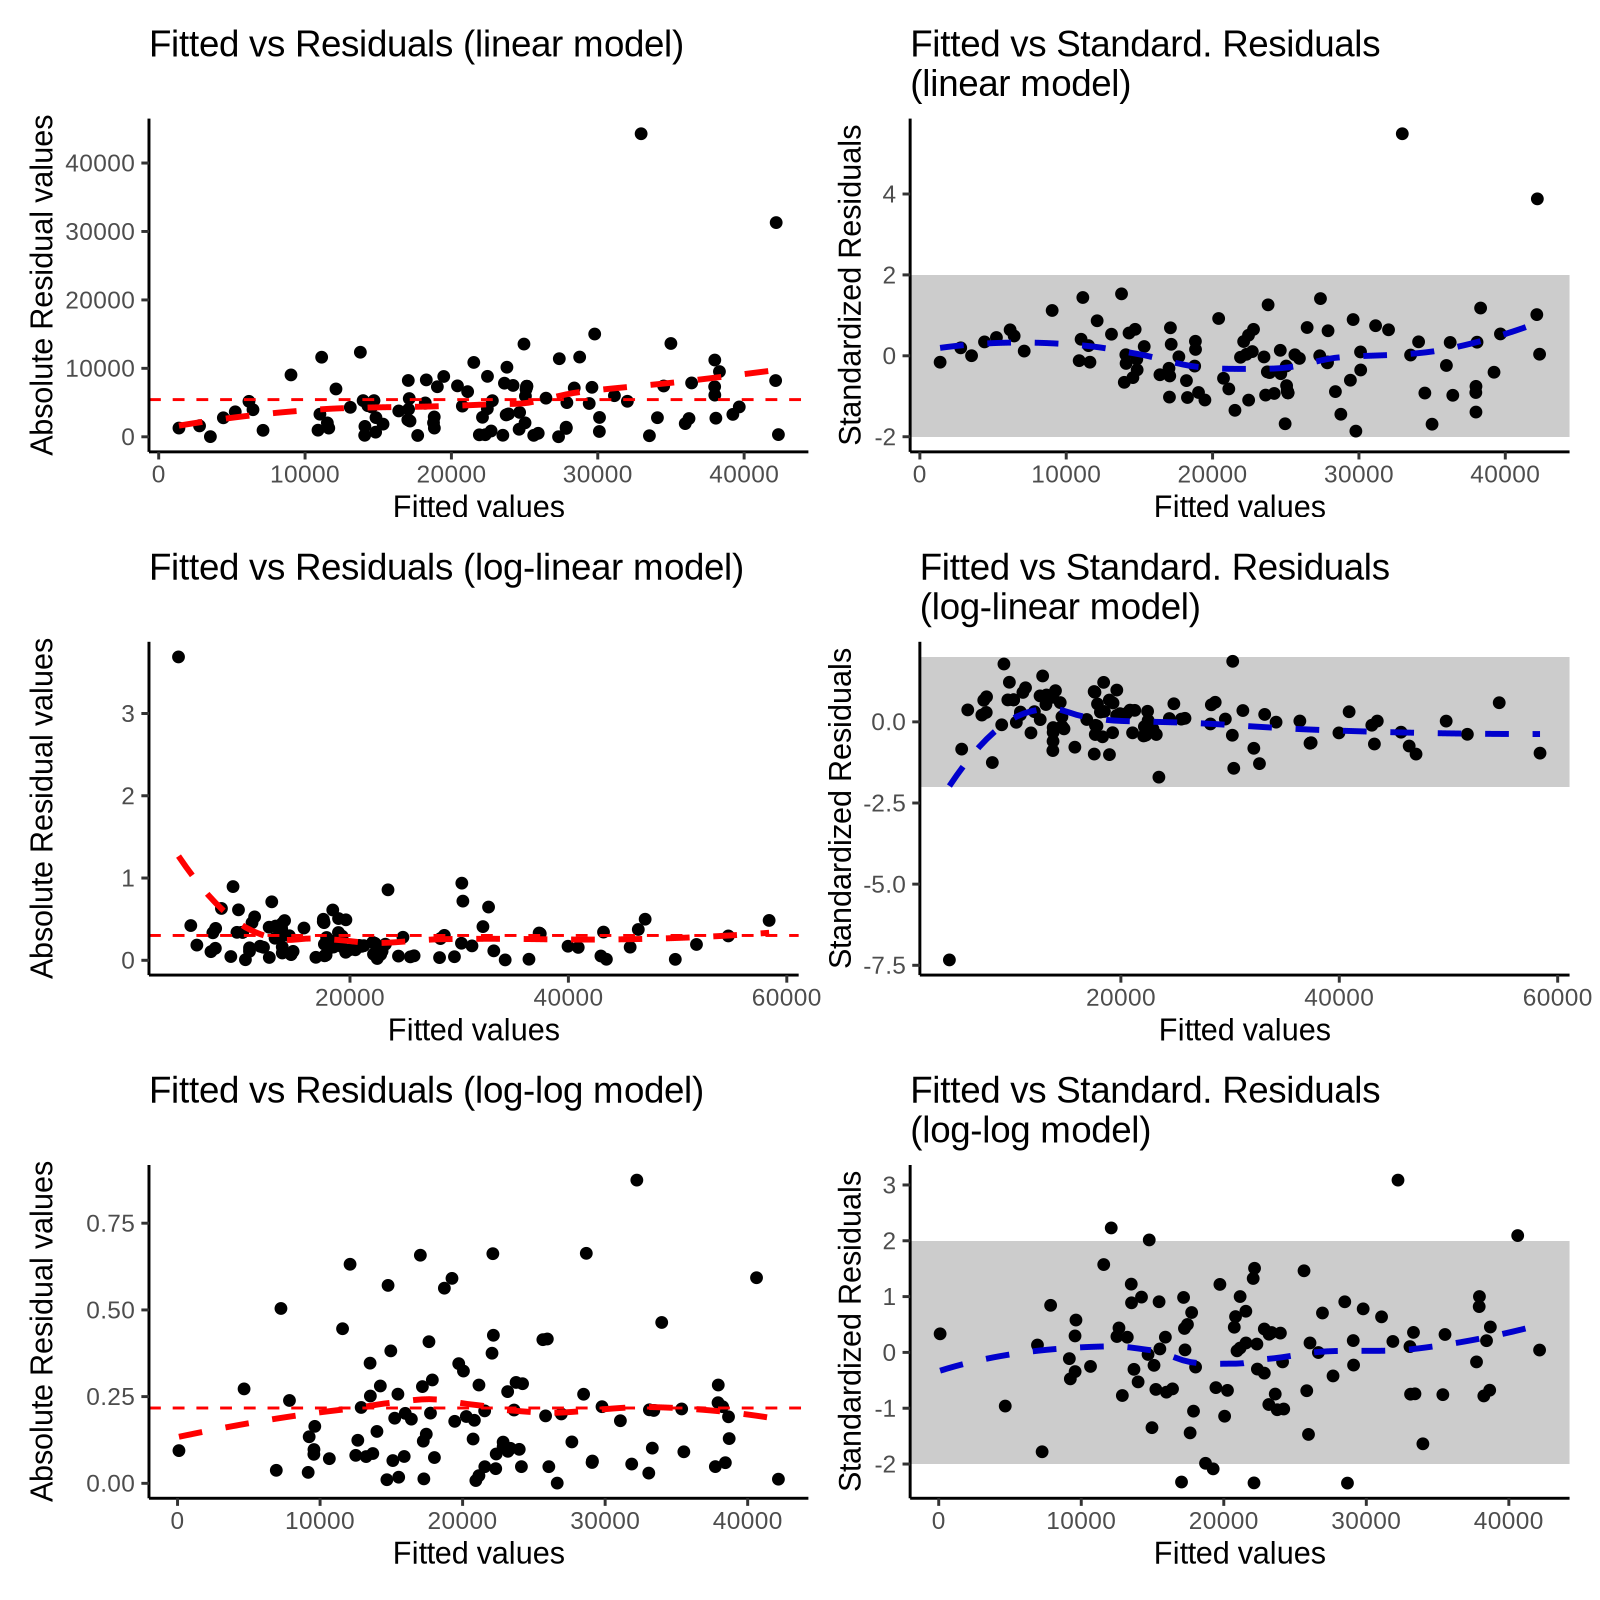

In [71]:
options(repr.plot.width = 8, repr.plot.height = 8, repr.plot.res = 200)

df$fitted <- fitted(model1)
df$residuals <- abs(residuals(model1))
df$residuals_standardized <- residuals(model1) / sd(residuals(model1))

plt1 <- ggplot(df, aes(x = fitted, y = residuals)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "red", linetype = "dashed") +
    geom_hline(yintercept = mean(df$residuals), color = "red", linetype = "dashed") +
    labs(x = "Fitted values", y = "Absolute Residual values", title = "Fitted vs Residuals (linear model)") +
    theme_classic()

plt2 <- ggplot(df, aes(x = fitted, y = residuals_standardized)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "blue", linetype = "dashed") +
    annotate("rect", xmin = -Inf, xmax = Inf, ymin = -2, ymax = 2, alpha = 0.2, fill = "black") +
    labs(x = "Fitted values", y = "Standardized Residuals", title = "Fitted vs Standard. Residuals\n(linear model)") +
    theme_classic()

df$fitted <- exp(fitted(model2))
df$residuals <- abs(residuals(model2))
df$residuals_standardized <- residuals(model2) / sd(residuals(model2))

plt3 <- ggplot(df, aes(x = fitted, y = residuals)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "red", linetype = "dashed") +
    geom_hline(yintercept = mean(df$residuals), color = "red", linetype = "dashed") +
    labs(x = "Fitted values", y = "Absolute Residual values", title = "Fitted vs Residuals (log-linear model)") +
    theme_classic()

plt4 <- ggplot(df, aes(x = fitted, y = residuals_standardized)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "blue", linetype = "dashed") +
    annotate("rect", xmin = -Inf, xmax = Inf, ymin = -2, ymax = 2, alpha = 0.2, fill = "black") +
    labs(x = "Fitted values", y = "Standardized Residuals", title = "Fitted vs Standard. Residuals\n(log-linear model)") +
    theme_classic()


# sigma2 <- summary(model3)$sigma^2
# bias_correction <- exp(sigma2 / 2)
# df$fitted <- exp(fitted(model3)) * bias_correction # this should have fixed the multiplicative error bias, but it is not enough
df$fitted <- exp(fitted(model3))
df$residuals <- abs(residuals(model3))
df$residuals_standardized <- residuals(model3) / sd(residuals(model3))

plt5 <- ggplot(df, aes(x = fitted, y = residuals)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "red", linetype = "dashed") +
    geom_hline(yintercept = mean(df$residuals), color = "red", linetype = "dashed") +
    labs(x = "Fitted values", y = "Absolute Residual values", title = "Fitted vs Residuals (log-log model)") +
    theme_classic()

plt6 <- ggplot(df, aes(x = fitted, y = residuals_standardized)) +
    geom_point() +
    geom_smooth(formula = y ~ x, method = "loess", se = FALSE, color = "blue", linetype = "dashed") +
    annotate("rect", xmin = -Inf, xmax = Inf, ymin = -2, ymax = 2, alpha = 0.2, fill = "black") +
    labs(x = "Fitted values", y = "Standardized Residuals", title = "Fitted vs Standard. Residuals\n(log-log model)") +
    theme_classic()

(plt1 + plt2) / (plt3 + plt4) / (plt5 + plt6)


- If a model residuals increases or decreases with the magnitude of the fitted values, then we say that there is a heteroscedasticity in the model
- Plotting the absolute values of the residuals vs the fitted values helps us see this
- In this case the linear model, in particular, has heteroscedasticity in the model
